# Notebook 02 — Data Preprocessing

Covers both datasets:
- **PJM East** (`PJME_hourly.csv`) — regional grid-level hourly demand
- **UCI Household** (`household_power_consumption.csv`) — minute-level household power

Steps per dataset:
1. Load & inspect
2. Parse datetime & fill gaps
3. Outlier detection & clipping (IQR method)
4. Time feature extraction
5. Min-Max normalisation
6. Sequence windowing (24-hour look-back)
7. Save processed CSV + NumPy sequences

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pickle, os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

RAW  = os.path.join('..', 'data', 'raw')
PROC = os.path.join('..', 'data', 'processed')
os.makedirs(PROC, exist_ok=True)

WINDOW = 24   # 24-hour look-back window for sequence creation
print('Libraries loaded. WINDOW =', WINDOW)

Libraries loaded. WINDOW = 24


---
## Part 1 — PJM East Dataset

In [2]:
# ── 1. Load & Inspect ──────────────────────────────────────────────
pjm = pd.read_csv(os.path.join(RAW, 'PJME_hourly.csv'))
print(f'Shape : {pjm.shape}')
print(f'Dtypes:\n{pjm.dtypes}\n')
pjm.head()

Shape : (145366, 2)
Dtypes:
Datetime        str
PJME_MW     float64
dtype: object



,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
# ── 2. Parse Datetime, Sort & Fill Gaps ───────────────────────────
pjm['Datetime'] = pd.to_datetime(pjm['Datetime'])
pjm = pjm.sort_values('Datetime').reset_index(drop=True)
pjm = pjm.set_index('Datetime')

print('Missing values before reindex:')
print(pjm.isnull().sum())

# Remove duplicate timestamps (keep first occurrence)
dupes = pjm.index.duplicated(keep='first').sum()
print(f'\nDuplicate timestamps removed : {dupes}')
pjm = pjm[~pjm.index.duplicated(keep='first')]

# Reindex to a full hourly range so gaps become explicit NaNs
full_idx = pd.date_range(start=pjm.index.min(), end=pjm.index.max(), freq='h')
pjm = pjm.reindex(full_idx)
print(f'Rows after full reindex : {len(pjm):,}')
print(f'NaNs introduced by gaps : {pjm.isnull().sum().values[0]:,}')

pjm = pjm.ffill().bfill()
pjm.index.name = 'Datetime'
print(f'Remaining NaNs          : {pjm.isnull().sum().values[0]}')
pjm.describe()

Missing values before reindex:
PJME_MW    0
dtype: int64

Duplicate timestamps removed : 4
Rows after full reindex : 145,392
NaNs introduced by gaps : 30
Remaining NaNs          : 0


,PJME_MW
count,145392.000000
mean,32079.051915
std,6464.154020
min,14544.000000
25%,27571.000000
50%,31420.000000
75%,35647.250000
max,62009.000000


Outliers detected : 3,460  (2.38%)
  Lower bound : 15,456.6 MW
  Upper bound : 47,761.6 MW


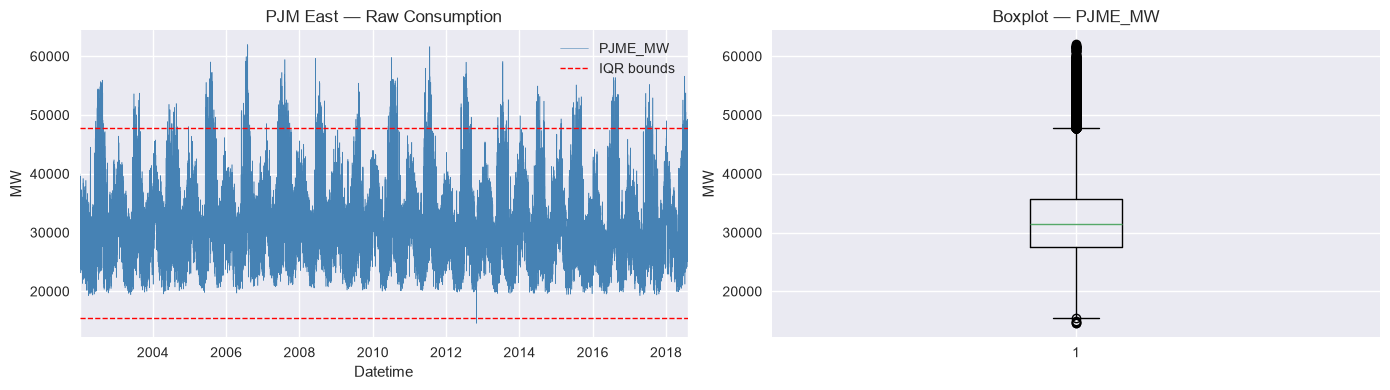


Outliers clipped to IQR bounds.


In [4]:
# ── 3. Outlier Detection & Clipping (IQR) ─────────────────────────
col = 'PJME_MW'
Q1, Q3 = pjm[col].quantile(0.25), pjm[col].quantile(0.75)
IQR    = Q3 - Q1
lower  = Q1 - 1.5 * IQR
upper  = Q3 + 1.5 * IQR

mask     = (pjm[col] < lower) | (pjm[col] > upper)
print(f'Outliers detected : {mask.sum():,}  ({mask.mean()*100:.2f}%)')
print(f'  Lower bound : {lower:,.1f} MW')
print(f'  Upper bound : {upper:,.1f} MW')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pjm[col].plot(ax=axes[0], lw=0.4, color='steelblue',
              title='PJM East — Raw Consumption')
axes[0].axhline(lower, color='red', ls='--', lw=1, label='IQR bounds')
axes[0].axhline(upper, color='red', ls='--', lw=1)
axes[0].set_ylabel('MW')
axes[0].legend()
axes[1].boxplot(pjm[col], vert=True)
axes[1].set_title('Boxplot — PJME_MW')
axes[1].set_ylabel('MW')
plt.tight_layout()
plt.show()

pjm[col] = pjm[col].clip(lower, upper)
print('\nOutliers clipped to IQR bounds.')

In [5]:
# ── 4. Time Feature Extraction ────────────────────────────────────
def get_season(month):
    if month in [12, 1, 2]:  return 0   # Winter
    if month in [3,  4, 5]:  return 1   # Spring
    if month in [6,  7, 8]:  return 2   # Summer
    return 3                             # Autumn

pjm_feat = pjm.copy()
pjm_feat['hour']         = pjm_feat.index.hour
pjm_feat['day_of_week']  = pjm_feat.index.dayofweek   # 0=Mon
pjm_feat['day_of_month'] = pjm_feat.index.day
pjm_feat['month']        = pjm_feat.index.month
pjm_feat['year']         = pjm_feat.index.year
pjm_feat['is_weekend']   = (pjm_feat.index.dayofweek >= 5).astype(int)
pjm_feat['season']       = pjm_feat['month'].map(get_season)

print(f'Shape after feature extraction : {pjm_feat.shape}')
print(f'Columns : {list(pjm_feat.columns)}')
pjm_feat.head()

Shape after feature extraction : (145392, 8)
Columns : ['PJME_MW', 'hour', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'season']


,PJME_MW,hour,day_of_week,day_of_month,month,year,is_weekend,season
Datetime,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,0,0
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,0,0
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,0,0
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,0,0
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,0,0


In [6]:
# ── 5. Min-Max Normalisation ──────────────────────────────────────
pjm_scaler = MinMaxScaler()
pjm_feat['PJME_MW_scaled'] = pjm_scaler.fit_transform(pjm_feat[['PJME_MW']])

with open(os.path.join(PROC, 'pjm_scaler.pkl'), 'wb') as f:
    pickle.dump(pjm_scaler, f)

print(f"Scaled min : {pjm_feat['PJME_MW_scaled'].min():.4f}")
print(f"Scaled max : {pjm_feat['PJME_MW_scaled'].max():.4f}")
print('Scaler saved → pjm_scaler.pkl')
pjm_feat[['PJME_MW', 'PJME_MW_scaled']].head()

Scaled min : 0.0000
Scaled max : 1.0000
Scaler saved → pjm_scaler.pkl


,PJME_MW,PJME_MW_scaled
Datetime,,
2002-01-01 01:00:00,30393.0,0.462355
2002-01-01 02:00:00,29265.0,0.427438
2002-01-01 03:00:00,28357.0,0.399331
2002-01-01 04:00:00,27899.0,0.385153
2002-01-01 05:00:00,28057.0,0.390044


In [7]:
# ── 6. Sequence Windowing ─────────────────────────────────────────
# Each sample: 24 consecutive hours → predict the next hour
values = pjm_feat['PJME_MW_scaled'].values

X_p, y_p = [], []
for i in range(WINDOW, len(values)):
    X_p.append(values[i - WINDOW : i])
    y_p.append(values[i])

X_p = np.array(X_p)   # (samples, 24)
y_p = np.array(y_p)   # (samples,)

# Chronological 80/20 split — no shuffling for time series
split = int(len(X_p) * 0.8)
X_train_p, X_test_p = X_p[:split], X_p[split:]
y_train_p, y_test_p = y_p[:split], y_p[split:]

print(f'Total sequences  : {len(X_p):,}')
print(f'Train sequences  : {len(X_train_p):,}  ({len(X_train_p)/len(X_p)*100:.0f}%)')
print(f'Test  sequences  : {len(X_test_p):,}  ({len(X_test_p)/len(X_p)*100:.0f}%)')
print(f'X_train shape    : {X_train_p.shape}')

Total sequences  : 145,368
Train sequences  : 116,294  (80%)
Test  sequences  : 29,074  (20%)
X_train shape    : (116294, 24)


In [8]:
# ── 7. Save PJM ───────────────────────────────────────────────────
pjm_feat.to_csv(os.path.join(PROC, 'pjm_processed.csv'))
np.savez(os.path.join(PROC, 'pjm_sequences.npz'),
         X_train=X_train_p, X_test=X_test_p,
         y_train=y_train_p, y_test=y_test_p)

print('Saved → pjm_processed.csv')
print('Saved → pjm_sequences.npz')

Saved → pjm_processed.csv
Saved → pjm_sequences.npz


---
## Part 2 — UCI Household Dataset

In [9]:
# ── 1. Load & Inspect ──────────────────────────────────────────────
# '?' marks missing values in the original dataset
uci = pd.read_csv(
    os.path.join(RAW, 'household_power_consumption.csv'),
    na_values='?',
    low_memory=False
)
print(f'Shape : {uci.shape}')
print(f'Dtypes:\n{uci.dtypes}\n')
uci.head()

Shape : (2075259, 9)
Dtypes:
Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object



,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
# ── 2. Combine Date + Time → Datetime, Sort ───────────────────────
uci['Datetime'] = pd.to_datetime(
    uci['Date'] + ' ' + uci['Time'],
    format='%d/%m/%Y %H:%M:%S'
)
uci = uci.drop(columns=['Date', 'Time'])
uci = uci.set_index('Datetime').sort_index()

print('Missing values per column:')
miss = uci.isnull().sum()
print(miss)
print(f'\nTotal missing: {miss.sum():,}  ({miss.sum()/uci.size*100:.2f}%)')

Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Total missing: 181,853  (1.25%)


In [11]:
# ── 3. Resample to Hourly & Fill Gaps ────────────────────────────
# Average all minute readings within each hour
uci_h = uci.resample('h').mean()
print(f'Shape after hourly resample : {uci_h.shape}')

uci_h = uci_h.ffill().bfill()
remaining = uci_h.isnull().sum().sum()
print(f'Remaining NaNs after fill   : {remaining}')
uci_h.describe()

Shape after hourly resample : (34589, 7)
Remaining NaNs after fill   : 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.089029,0.123379,240.837011,4.616290,1.123637,1.293541,6.421429
std,0.895663,0.066976,3.005611,3.749086,3.536759,4.172246,7.343298
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.342233,0.077967,239.196667,1.516667,0.000000,0.000000,0.650000
50%,0.804933,0.106933,240.965667,3.430000,0.000000,0.333333,1.650000
75%,1.575300,0.149167,242.707000,6.583333,0.000000,0.650000,14.083333
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


Outliers detected : 740  (2.14%)
  Lower bound : -1.5074 kW
  Upper bound : 3.4249 kW


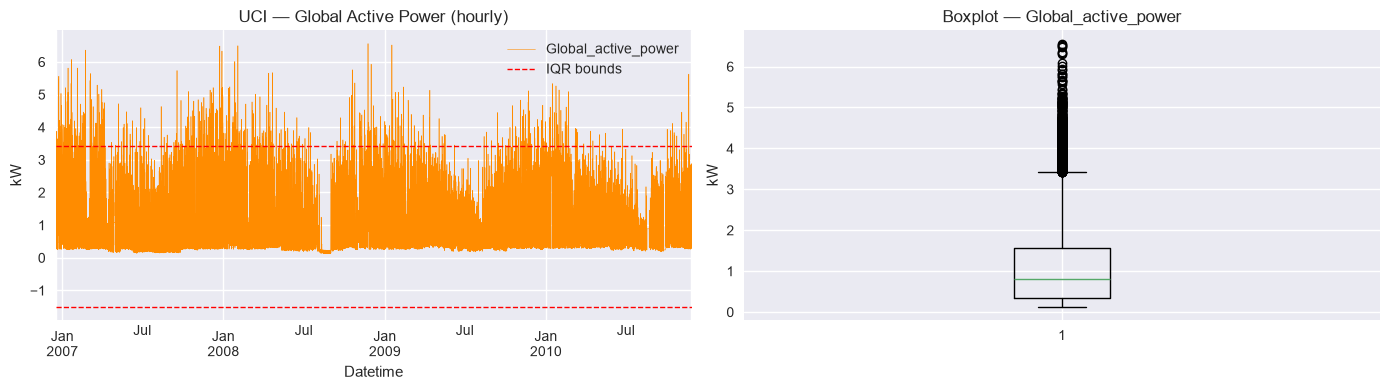


Outliers clipped to IQR bounds.


In [12]:
# ── 4. Outlier Detection & Clipping on Global_active_power ────────
col  = 'Global_active_power'
Q1u  = uci_h[col].quantile(0.25)
Q3u  = uci_h[col].quantile(0.75)
IQRu = Q3u - Q1u
lu   = Q1u - 1.5 * IQRu
uu   = Q3u + 1.5 * IQRu

masku = (uci_h[col] < lu) | (uci_h[col] > uu)
print(f'Outliers detected : {masku.sum():,}  ({masku.mean()*100:.2f}%)')
print(f'  Lower bound : {lu:.4f} kW')
print(f'  Upper bound : {uu:.4f} kW')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
uci_h[col].plot(ax=axes[0], lw=0.4, color='darkorange',
                title='UCI — Global Active Power (hourly)')
axes[0].axhline(lu, color='red', ls='--', lw=1, label='IQR bounds')
axes[0].axhline(uu, color='red', ls='--', lw=1)
axes[0].set_ylabel('kW')
axes[0].legend()
axes[1].boxplot(uci_h[col], vert=True)
axes[1].set_title('Boxplot — Global_active_power')
axes[1].set_ylabel('kW')
plt.tight_layout()
plt.show()

uci_h[col] = uci_h[col].clip(lu, uu)
print('\nOutliers clipped to IQR bounds.')

In [13]:
# ── 5. Time Feature Extraction ────────────────────────────────────
uci_feat = uci_h.copy()
uci_feat['hour']         = uci_feat.index.hour
uci_feat['day_of_week']  = uci_feat.index.dayofweek
uci_feat['day_of_month'] = uci_feat.index.day
uci_feat['month']        = uci_feat.index.month
uci_feat['year']         = uci_feat.index.year
uci_feat['is_weekend']   = (uci_feat.index.dayofweek >= 5).astype(int)
uci_feat['season']       = uci_feat['month'].map(get_season)

print(f'Shape : {uci_feat.shape}')
print(f'Columns : {list(uci_feat.columns)}')
uci_feat.head()

Shape : (34589, 14)
Columns : ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 'season']


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,day_of_month,month,year,is_weekend,season
Datetime,,,,,,,,,,,,,,
2006-12-16 17:00:00,3.424900,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,16,12,2006,1,0
2006-12-16 18:00:00,3.424900,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,16,12,2006,1,0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,16,12,2006,1,0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,16,12,2006,1,0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,16,12,2006,1,0


In [14]:
# ── 6. Min-Max Normalisation ──────────────────────────────────────
uci_scaler = MinMaxScaler()
uci_feat['GAP_scaled'] = uci_scaler.fit_transform(
    uci_feat[['Global_active_power']]
)

with open(os.path.join(PROC, 'uci_scaler.pkl'), 'wb') as f:
    pickle.dump(uci_scaler, f)

print(f"Scaled min : {uci_feat['GAP_scaled'].min():.4f}")
print(f"Scaled max : {uci_feat['GAP_scaled'].max():.4f}")
print('Scaler saved → uci_scaler.pkl')
uci_feat[['Global_active_power', 'GAP_scaled']].head()

Scaled min : 0.0000
Scaled max : 1.0000
Scaler saved → uci_scaler.pkl


,Global_active_power,GAP_scaled
Datetime,,
2006-12-16 17:00:00,3.424900,1.000000
2006-12-16 18:00:00,3.424900,1.000000
2006-12-16 19:00:00,3.400233,0.992527
2006-12-16 20:00:00,3.268567,0.952639
2006-12-16 21:00:00,3.056467,0.888384


In [15]:
# ── 7. Sequence Windowing ─────────────────────────────────────────
values_u = uci_feat['GAP_scaled'].values

X_u, y_u = [], []
for i in range(WINDOW, len(values_u)):
    X_u.append(values_u[i - WINDOW : i])
    y_u.append(values_u[i])

X_u = np.array(X_u)
y_u = np.array(y_u)

split_u = int(len(X_u) * 0.8)
X_train_u, X_test_u = X_u[:split_u], X_u[split_u:]
y_train_u, y_test_u = y_u[:split_u], y_u[split_u:]

print(f'Total sequences  : {len(X_u):,}')
print(f'Train sequences  : {len(X_train_u):,}  ({len(X_train_u)/len(X_u)*100:.0f}%)')
print(f'Test  sequences  : {len(X_test_u):,}  ({len(X_test_u)/len(X_u)*100:.0f}%)')
print(f'X_train shape    : {X_train_u.shape}')

Total sequences  : 34,565
Train sequences  : 27,652  (80%)
Test  sequences  : 6,913  (20%)
X_train shape    : (27652, 24)


In [16]:
# ── 8. Save UCI ───────────────────────────────────────────────────
uci_feat.to_csv(os.path.join(PROC, 'uci_processed.csv'))
np.savez(os.path.join(PROC, 'uci_sequences.npz'),
         X_train=X_train_u, X_test=X_test_u,
         y_train=y_train_u, y_test=y_test_u)

print('Saved → uci_processed.csv')
print('Saved → uci_sequences.npz')

Saved → uci_processed.csv
Saved → uci_sequences.npz


---
## Summary

In [17]:
print('=' * 55)
print('PREPROCESSING COMPLETE')
print('=' * 55)
print(f'\nPJM East (PJME_hourly):')
print(f'  Processed rows   : {len(pjm_feat):,}')
print(f'  Date range       : {pjm_feat.index[0].date()} → {pjm_feat.index[-1].date()}')
print(f'  Train sequences  : {len(X_train_p):,}')
print(f'  Test  sequences  : {len(X_test_p):,}')
print()
print(f'UCI Household:')
print(f'  Processed rows   : {len(uci_feat):,}')
print(f'  Date range       : {uci_feat.index[0].date()} → {uci_feat.index[-1].date()}')
print(f'  Train sequences  : {len(X_train_u):,}')
print(f'  Test  sequences  : {len(X_test_u):,}')
print()
print(f'Files saved to : {os.path.abspath(PROC)}')
print('  pjm_processed.csv  | pjm_sequences.npz  | pjm_scaler.pkl')
print('  uci_processed.csv  | uci_sequences.npz  | uci_scaler.pkl')

PREPROCESSING COMPLETE

PJM East (PJME_hourly):
  Processed rows   : 145,392
  Date range       : 2002-01-01 → 2018-08-03
  Train sequences  : 116,294
  Test  sequences  : 29,074

UCI Household:
  Processed rows   : 34,589
  Date range       : 2006-12-16 → 2010-11-26
  Train sequences  : 27,652
  Test  sequences  : 6,913

Files saved to : .../implementation/data/processed
  pjm_processed.csv  | pjm_sequences.npz  | pjm_scaler.pkl
  uci_processed.csv  | uci_sequences.npz  | uci_scaler.pkl
